# Libraries



In [1]:
import sklearn as sk
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np
from sklearn.manifold import TSNE
from sklearn import cluster
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn import preprocessing
from sklearn.manifold import SpectralEmbedding
import warnings
warnings.filterwarnings("ignore")

# Code

In [2]:
class clustering():
    def __init__(self,df):
        self.df=pd.DataFrame(preprocessing.StandardScaler().fit(df).transform(df))
        #self.df=df

        
    def plotter(self,x,y,action='only_scatter',c='yellow'):
        fig,ax=plt.subplots()
        ax.set_facecolor('black')
        
        if action=='scatter_and_plot':
            ax.plot(x,y,c=c)
            ax.scatter(x,y,c=c)
        if action=='only_plot':
            ax.plot(x,y,c=c)
        else:
            ax.scatter(x,y,c=c)
            
    def tsne(self,c='#1f77b4'):
        new_df=TSNE(n_components=2, verbose=1, random_state=123).fit_transform(df)
        x=new_df[:,0]
        y=new_df[:,1]
        self.plotter(x,y,c=c) 
        return x,y
        
    def Elbow(self):
        res=[]
        Silh=[]
        for k in range(2,10):    
            kmeans=cluster.KMeans(k,init='k-means++').fit(df)
            wss=kmeans.inertia_
            res.append(wss)
            s=sk.metrics.silhouette_score(df.values,kmeans.labels_)
            Silh.append(s)   
        self.plotter([i for i in range(2,10)],res,'scatter_and_plot')
        
        
    def link(self):
        return linkage(self.df, 'ward', 'euclidean')
    def dn(self):
        fig = plt.figure()

        ax1 = fig.add_subplot(111)
        ax1.set_xlabel('Схожесть стран')
        ax1.set_facecolor('black')
        ax1.set_title('Дендрограмма')

        return dendrogram(self.link(), labels= self.df.index.tolist())
    def hierarchic_labels_(self,l):
        return fcluster(self.link(),l, criterion='distance')
    def plot_hierarchic(self,l):
        self.tsne(c=self.hierarchic_labels_(l))
        
        
    def KMeans_labels_(self,k):
        kmeans=cluster.KMeans(k,init='k-means++').fit(self.df)
        return kmeans.labels_
    def plot_KMeans(self,k):
        self.tsne(c=self.KMeans_labels_(k))
        
        
    def dbscan_labels_(self,eps,min_samples=2):
        dbscan_3 = DBSCAN(eps=eps, metric='euclidean', min_samples=min_samples, algorithm= 'brute').fit(df)
        return dbscan_3.labels_
    def plot_dbscan(self,eps,min_samples=2):
        self.tsne(c=self.dbscan_labels_(eps,min_samples))
        
    def SC_labels_(self,n):
        sc=cluster.SpectralClustering(n_clusters=n).fit(self.df)
        return sc.labels_
    
    def SC_eigenvects(self,n):
        X=self.df
        embedding = SpectralEmbedding(n_components=n)
        X_transformed = embedding.fit_transform(X)
        return X_transformed
    
    def plot_SC(self,n):
        self.tsne(c=self.SC_labels_(n))

#  data

In [3]:
file=r'C:\Users\ILYA\Desktop\HSE\third year\аббакумов\Леденцы.dat'

In [4]:
df=pd.read_csv(file,sep=';')
df1=df.copy()
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11
0,4,5,5,5,3,3,3,3,3,3,3
1,5,4,5,5,3,3,3,3,3,3,3
2,5,5,4,5,3,3,3,3,3,3,3
3,5,4,5,5,3,3,3,3,3,3,3
4,4,5,5,5,3,3,3,3,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...
333,3,3,3,3,3,3,5,5,3,3,3
334,3,3,3,3,3,3,5,5,3,3,3
335,3,3,3,3,3,3,5,5,3,3,3
336,3,3,3,3,3,3,5,5,3,3,3


In [5]:
model=clustering(df)

In [6]:
model.df

,0,1,2,3,4,5,6,7,8,9,10
0,0.477424,1.542809,1.499214,1.603442,-0.239138,-0.235068,-0.301875,-0.353342,-0.623343,-0.594459,-0.600745
1,1.525275,0.495682,1.499214,1.603442,-0.239138,-0.235068,-0.301875,-0.353342,-0.623343,-0.594459,-0.600745
2,1.525275,1.542809,0.487768,1.603442,-0.239138,-0.235068,-0.301875,-0.353342,-0.623343,-0.594459,-0.600745
3,1.525275,0.495682,1.499214,1.603442,-0.239138,-0.235068,-0.301875,-0.353342,-0.623343,-0.594459,-0.600745
4,0.477424,1.542809,1.499214,1.603442,-0.239138,-0.235068,-0.301875,-0.353342,-0.623343,-0.594459,-0.600745
...,...,...,...,...,...,...,...,...,...,...,...
333,-0.570428,-0.551446,-0.523678,-0.415044,-0.239138,-0.235068,2.071004,2.083996,-0.623343,-0.594459,-0.600745
334,-0.570428,-0.551446,-0.523678,-0.415044,-0.239138,-0.235068,2.071004,2.083996,-0.623343,-0.594459,-0.600745
335,-0.570428,-0.551446,-0.523678,-0.415044,-0.239138,-0.235068,2.071004,2.083996,-0.623343,-0.594459,-0.600745
336,-0.570428,-0.551446,-0.523678,-0.415044,-0.239138,-0.235068,2.071004,2.083996,-0.623343,-0.594459,-0.600745


# n-clusters=?



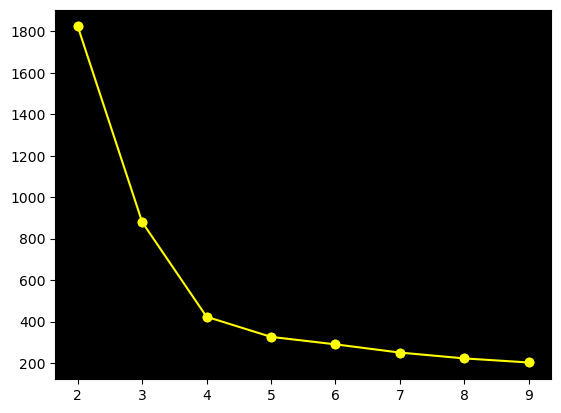

In [7]:
model.Elbow()

## Видно, что после 4 точки угол наклона изменяется слабо, поэтому кластеров 4.

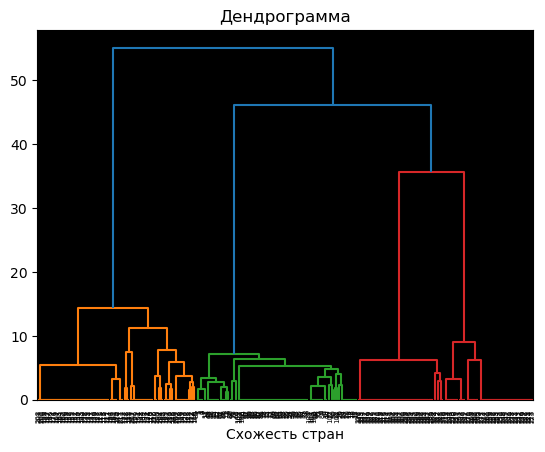

In [8]:
dn=model.dn()

## Tут видно 4 большие линии. Значит объеденяются 4 кластера, которые не похожи друг-на-друга. Поэтому n=4

# Hierarchical clustering

In [9]:
df1['hierarchical clustering']=model.hierarchic_labels_(20)
df1

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,hierarchical clustering
0,4,5,5,5,3,3,3,3,3,3,3,2
1,5,4,5,5,3,3,3,3,3,3,3,2
2,5,5,4,5,3,3,3,3,3,3,3,2
3,5,4,5,5,3,3,3,3,3,3,3,2
4,4,5,5,5,3,3,3,3,3,3,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...
333,3,3,3,3,3,3,5,5,3,3,3,3
334,3,3,3,3,3,3,5,5,3,3,3,3
335,3,3,3,3,3,3,5,5,3,3,3,3
336,3,3,3,3,3,3,5,5,3,3,3,3


# Kmeans


In [10]:
df1['KMeans clustering']=model.KMeans_labels_(4)
df1

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,hierarchical clustering,KMeans clustering
0,4,5,5,5,3,3,3,3,3,3,3,2,1
1,5,4,5,5,3,3,3,3,3,3,3,2,1
2,5,5,4,5,3,3,3,3,3,3,3,2,1
3,5,4,5,5,3,3,3,3,3,3,3,2,1
4,4,5,5,5,3,3,3,3,3,3,3,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,3,3,3,3,3,3,5,5,3,3,3,3,3
334,3,3,3,3,3,3,5,5,3,3,3,3,3
335,3,3,3,3,3,3,5,5,3,3,3,3,3
336,3,3,3,3,3,3,5,5,3,3,3,3,3


# DBSCAN


### слишком много кластеров

In [11]:
table_ = pd.value_counts(pd.Series(model.dbscan_labels_(eps=0.1,min_samples=2)))
table_.sort_index(inplace=True)

print(min(table_.index),table_[min(table_.index)])
print(max(table_.index),table_[max(table_.index)])

-1 14
30 2


### слишком мало кластеров

In [12]:
table_ = pd.value_counts(pd.Series(model.dbscan_labels_(eps=3,min_samples=2)))
table_.sort_index(inplace=True)

print(min(table_.index),table_[min(table_.index)])
print(max(table_.index),table_[max(table_.index)])

0 338
0 338


#  Silhouette для автоматического определения значений параметров
###           too many clusters

In [13]:
eps_1 = np.arange(0.1,3,0.1)
min_samples_1 = [2, 3, 4, 5, 10, 15, 20, 25]
sil_avg = []
max_value = [0, 0, 0, -1]

In [14]:
#  Перебираю все пары значений параметров
#  Сохраняю лучшее решение

for i in range(len(eps_1)):
    for j in range(len(min_samples_1)):

        db = DBSCAN(min_samples = min_samples_1[j], eps =eps_1[i]).fit(df)
        
        labels = db.labels_

        # Число кластеров, после отбрасывания выбросов.
        n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)

        # Число выбросов.
        # n_noise_ = list(labels).count(-1)

        if n_clusters_ > 1:
            silhouette_avg = metrics.silhouette_score(df, labels)
            if silhouette_avg > max_value[3]:
                max_value=(eps_1[i], min_samples_1[j], n_clusters_, silhouette_avg)
            sil_avg.append(silhouette_avg)

print("epsilon=", max_value[0], 
      "\nmin_sample=", max_value[1],
      "\nnumber of clusters=", max_value[2],
      "\naverage silhouette score= %.4f" % max_value[3])

epsilon= 0.1 
min_sample= 2 
number of clusters= 31 
average silhouette score= 0.9312


# Найдем  eps  s.t  number of clusters=4

In [15]:
set(model.dbscan_labels_(eps=2.2,min_samples=2))

{0, 1, 2, 3}

In [16]:
df1['DBSCAN']=model.dbscan_labels_(eps=2.2,min_samples=2)
df1

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,hierarchical clustering,KMeans clustering,DBSCAN
0,4,5,5,5,3,3,3,3,3,3,3,2,1,0
1,5,4,5,5,3,3,3,3,3,3,3,2,1,0
2,5,5,4,5,3,3,3,3,3,3,3,2,1,0
3,5,4,5,5,3,3,3,3,3,3,3,2,1,0
4,4,5,5,5,3,3,3,3,3,3,3,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,3,3,3,3,3,3,5,5,3,3,3,3,3,3
334,3,3,3,3,3,3,5,5,3,3,3,3,3,3
335,3,3,3,3,3,3,5,5,3,3,3,3,3,3
336,3,3,3,3,3,3,5,5,3,3,3,3,3,3


# Spectral Clustering (additional)


In [17]:
df1['Spectral clustering']=model.SC_labels_(4)
df1

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,hierarchical clustering,KMeans clustering,DBSCAN,Spectral clustering
0,4,5,5,5,3,3,3,3,3,3,3,2,1,0,1
1,5,4,5,5,3,3,3,3,3,3,3,2,1,0,1
2,5,5,4,5,3,3,3,3,3,3,3,2,1,0,1
3,5,4,5,5,3,3,3,3,3,3,3,2,1,0,1
4,4,5,5,5,3,3,3,3,3,3,3,2,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,3,3,3,3,3,3,5,5,3,3,3,3,3,3,3
334,3,3,3,3,3,3,5,5,3,3,3,3,3,3,3
335,3,3,3,3,3,3,5,5,3,3,3,3,3,3,3
336,3,3,3,3,3,3,5,5,3,3,3,3,3,3,3


In [18]:
vects=model.SC_eigenvects(4)
len(model.SC_labels_(4))

338

In [19]:
sp_data=pd.DataFrame({'labels':model.SC_labels_(4),'vect_1':vects.T[0],'vect_2':vects.T[1],'vect_3':vects.T[2],'vect_4':vects.T[3]})

In [20]:
g0=sp_data.loc[sp_data['labels']==0].T[3:].T
g1=sp_data.loc[sp_data['labels']==1].T[3:].T
g0.values

array([[-7.51966807e-16, -1.22770091e-17],
       [-7.95049238e-16, -1.44685940e-17],
       [-8.20369278e-16, -5.78743759e-18],
       [-8.06624114e-16,  2.89371879e-18],
       [-7.89985231e-16, -2.89371879e-18],
       [-7.55036059e-16, -1.22770091e-17],
       [-7.56141912e-16, -4.30850092e-18],
       [-7.50756285e-16, -8.61700184e-18],
       [-7.49679160e-16, -8.61700184e-18],
       [-7.53987661e-16, -4.30850092e-18],
       [-8.05900684e-16,  4.77580662e-57],
       [-7.50943723e-16, -8.18467273e-18],
       [-7.54012975e-16, -1.22770091e-17],
       [-7.59373287e-16, -4.30850092e-18],
       [-7.55064786e-16, -4.30850092e-18],
       [-7.56059143e-16, -1.22770091e-17],
       [-7.58296162e-16, -4.30850092e-18],
       [-7.39065098e-16, -8.66938531e-18],
       [-8.08070973e-16, -5.78743759e-18],
       [-7.49075534e-16, -8.41657903e-18],
       [-7.41232444e-16, -8.66938531e-18],
       [-8.04453824e-16,  4.79923686e-57],
       [-7.57082227e-16, -1.22770091e-17],
       [-7.

# Validity of clustering
### лучший, наверное, способ определить качество кластеризации-это посмотреть на кластеры ( TSNE в помощь)



# Hierarchical clustering
### тут все хорошо

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 338 samples in 0.001s...
[t-SNE] Computed neighbors for 338 samples in 0.004s...
[t-SNE] Computed conditional probabilities for sample 338 / 338
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 37.088379
[t-SNE] KL divergence after 1000 iterations: -4.176086


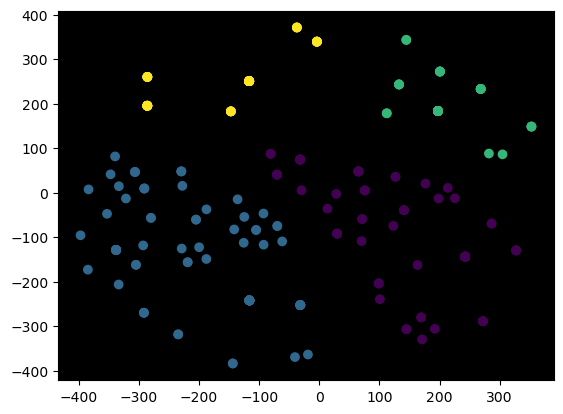

In [21]:
model.plot_hierarchic(20)

# Kmeans
### тут тоже все хорошо

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 338 samples in 0.000s...
[t-SNE] Computed neighbors for 338 samples in 0.008s...
[t-SNE] Computed conditional probabilities for sample 338 / 338
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 37.088379
[t-SNE] KL divergence after 1000 iterations: -4.176086


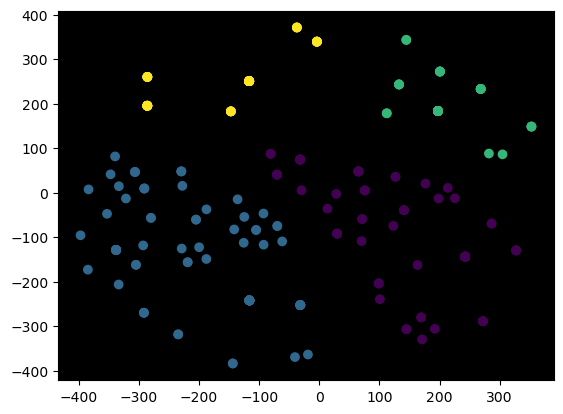

In [71]:
model.plot_KMeans(4)

# DBSCAN
### а тут неочень хорошо

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 338 samples in 0.007s...
[t-SNE] Computed neighbors for 338 samples in 0.008s...
[t-SNE] Computed conditional probabilities for sample 338 / 338
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 37.088379
[t-SNE] KL divergence after 1000 iterations: -4.176086


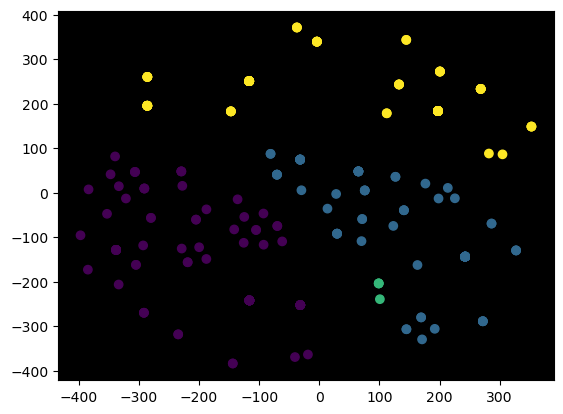

In [72]:
model.plot_dbscan(eps=2.2)

# Spectral clustering
### тут все просто отлично

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 338 samples in 0.000s...
[t-SNE] Computed neighbors for 338 samples in 0.008s...
[t-SNE] Computed conditional probabilities for sample 338 / 338
[t-SNE] Mean sigma: 0.000000
[t-SNE] KL divergence after 250 iterations with early exaggeration: 37.088379
[t-SNE] KL divergence after 1000 iterations: -4.176086


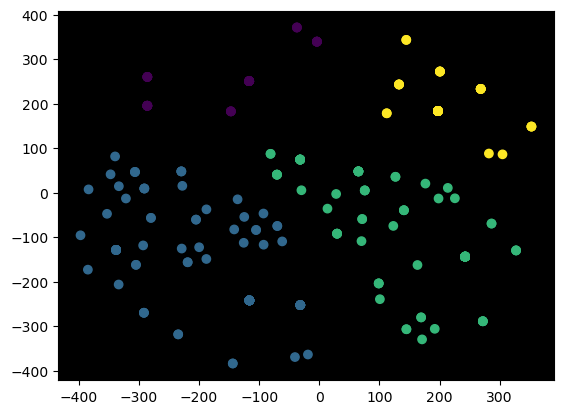

In [73]:
model.plot_SC(4)

# Results&Interpretation&Conclusion


### Кластеризация потребителей при помощи разных методов
### C кластеризацией справились все алгоритмы, кроме DBSCAN

In [74]:
df1

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,hierarchical clustering,KMeans clustering,DBSCAN,Spectral clustering
0,4,5,5,5,3,3,3,3,3,3,3,2,0,0,0
1,5,4,5,5,3,3,3,3,3,3,3,2,0,0,0
2,5,5,4,5,3,3,3,3,3,3,3,2,0,0,0
3,5,4,5,5,3,3,3,3,3,3,3,2,0,0,0
4,4,5,5,5,3,3,3,3,3,3,3,2,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,3,3,3,3,3,3,5,5,3,3,3,3,3,3,3
334,3,3,3,3,3,3,5,5,3,3,3,3,3,3,3
335,3,3,3,3,3,3,5,5,3,3,3,3,3,3,3
336,3,3,3,3,3,3,5,5,3,3,3,3,3,3,3


# Анализ средних значений оценок


### видно, что в первой группе самые большие средние у V9  V10 and V11

In [75]:
pd.DataFrame({'mean':df1.loc[df1['hierarchical clustering']==1,df1.columns[:11]].mean(),'count':[len(df1.loc[df1['hierarchical clustering']==1,df1.columns[:11]])]*11})

,mean,count
V1,2.824074,108
V2,2.833333,108
V3,2.768519,108
V4,2.620370,108
V5,2.611111,108
V6,2.583333,108
V7,2.750000,108
V8,2.916667,108
V9,4.953704,108
V10,4.814815,108


### видно, что во второй группе самые большие средние у V1 V2 V3 and V4

In [76]:
pd.DataFrame({'mean':df1.loc[df1['hierarchical clustering']==2,df1.columns[:11]].mean(),'count':[len(df1.loc[df1['hierarchical clustering']==2,df1.columns[:11]])]*11})

,mean,count
V1,4.845455,110
V2,4.800000,110
V3,4.836364,110
V4,4.681818,110
V5,3.036364,110
V6,3.036364,110
V7,3.000000,110
V8,2.990909,110
V9,3.072727,110
V10,3.045455,110


### видно, что в четвертой группе самые большие средние у V5 and V6

In [77]:
pd.DataFrame({'mean':df1.loc[df1['hierarchical clustering']==4,df1.columns[:11]].mean(),'count':[len(df1.loc[df1['hierarchical clustering']==4,df1.columns[:10]])]*11})

,mean,count
V1,3.000000,61
V2,3.000000,61
V3,3.000000,61
V4,3.000000,61
V5,4.852459,61
V6,4.852459,61
V7,3.000000,61
V8,2.918033,61
V9,2.754098,61
V10,2.754098,61


### видно, что в третьей группе самые большие средние у V7  V8  

In [78]:
pd.DataFrame({'mean':df1.loc[df1['hierarchical clustering']==3,df1.columns[:11]].mean(),'count':[len(df1.loc[df1['hierarchical clustering']==3,df1.columns[:11]])]*11})

,mean,count
V1,3.000000,59
V2,2.966102,59
V3,2.966102,59
V4,2.915254,59
V5,2.915254,59
V6,2.949153,59
V7,4.915254,59
V8,4.915254,59
V9,3.000000,59
V10,3.000000,59


# Result
### Кластеризация показала, что существуют 4 группы клиентов.
### Первая группа поддерживает удтверждения V9 V10 V11 
### Вторая группа поддерживает удтверждения V1 V2 V3 and V4
### Третья группа поддерживает удтверждения V7 V8
### Четвертая группа поддерживает удтверждения V5 V6

In [79]:
df1.loc[df1['hierarchical clustering']==1]

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,hierarchical clustering,KMeans clustering,DBSCAN,Spectral clustering
110,3,2,2,2,3,2,2,3,5,5,5,1,2,1,1
111,3,3,3,3,3,3,3,3,5,5,5,1,2,1,1
112,2,4,4,4,2,2,2,3,5,5,5,1,2,2,1
113,3,3,3,3,3,3,3,3,5,5,5,1,2,1,1
114,3,3,3,3,3,3,3,3,5,5,5,1,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
213,3,3,3,3,3,3,3,3,4,4,5,1,2,1,1
214,3,3,3,3,3,3,3,3,4,4,5,1,2,1,1
215,2,2,2,2,2,2,2,3,5,5,5,1,2,1,1
216,3,2,2,2,3,3,4,4,5,5,5,1,2,1,1
